# Network Science - UDD

## Modelos nulos y baselines en redes


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---
Este notebook muestra cómo usar baselines y modelos nulos para evitar interpretaciones espurias en redes **tradicionales** y **bipartitas**.

## Objetivos
1. Comparar una red real con un baseline **ER** emparejado en tamaño y densidad.
2. Usar un **configuration model** para controlar por secuencia de grados.
3. Aplicar **degree-preserving rewiring** para medir estructura residual.
4. Construir un baseline tipo **SBM** cuando la hipótesis relevante es de bloques.
5. Mostrar un ejemplo de **weighted null** en una red real ponderada.
6. Mostrar por qué las **bipartitas requieren nulos propios**, especialmente antes de interpretar proyecciones 1-mode.

## Datasets públicos usados
- **Zachary Karate Club**: red social clásica, pública y ampliamente usada.
- **Les Misérables**: red ponderada de coapariciones entre personajes.
- **Davis Southern Women**: red bipartita clásica de afiliación evento–persona.

In [5]:
import math
import random
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

SEED = 42
rng = random.Random(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True



## 1. Funciones auxiliares

Las siguientes funciones resumen métricas útiles para **model checking**:

- tamaño y densidad
- clustering y transitividad
- assortativity
- tamaño del componente gigante
- distancias promedio sobre el componente gigante.

También dejamos funciones para:
- simular baselines repetidamente
- comparar la red real con distribuciones de métricas bajo distintos nulos
- trabajar con redes bipartitas y sus proyecciones.


In [6]:

def giant_component_subgraph(G): 
    ### Convierte a grafo simple si es multigrafo, luego encuentra el componente gigante y devuelve su subgrafo. Si el grafo es conexo, devuelve una copia del mismo.
    H = nx.Graph(G) if G.is_multigraph() else G.copy()
    if H.number_of_nodes() == 0:
        return H
    if nx.is_connected(H):
        return H
    nodes = max(nx.connected_components(H), key=len)
    return H.subgraph(nodes).copy()

def basic_metrics_undirected(G):
    ### Convierte a grafo simple si es multigrafo, luego calcula métricas básicas para un grafo no dirigido. Si el grafo es conexo, calcula métricas sobre el mismo; si no, calcula métricas sobre el componente gigante.
    ### Devuelve un diccionario con las métricas calculadas.
    H = nx.Graph(G) if G.is_multigraph() else G.copy()
    giant = giant_component_subgraph(H)
    deg = np.array([d for _, d in H.degree()])
    out = {
        "n": H.number_of_nodes(),
        "m": H.number_of_edges(),
        "density": nx.density(H),
        "avg_degree": float(deg.mean()),
        "degree_std": float(deg.std(ddof=0)),
        "clustering": nx.average_clustering(H),
        "transitivity": nx.transitivity(H),
        "assortativity": nx.degree_assortativity_coefficient(H),
        "giant_fraction": giant.number_of_nodes() / H.number_of_nodes(),
    }
    if giant.number_of_nodes() > 1:
        out["avg_path_giant"] = nx.average_shortest_path_length(giant)
        out["diameter_giant"] = nx.diameter(giant)
    else:
        out["avg_path_giant"] = np.nan
        out["diameter_giant"] = np.nan
    return out

def compare_real_vs_simulations(real_metrics, sim_df, metrics):
    ### Compara las métricas reales con las simuladas y devuelve un DataFrame con los resultados.
    rows = []
    for metric in metrics:
        sim_mean = sim_df[metric].mean()
        sim_std = sim_df[metric].std(ddof=0)
        z = np.nan if sim_std == 0 else (real_metrics[metric] - sim_mean) / sim_std
        rows.append({
            "metric": metric,
            "real": real_metrics[metric],
            "sim_mean": sim_mean,
            "sim_std": sim_std,
            "z_like": z,
        })
    return pd.DataFrame(rows)

def plot_metric_distributions(sim_df, real_metrics, metrics, title_prefix=""):
    ### Plotea histogramas de las métricas simuladas y marca el valor real con una línea vertical. Cada métrica se plotea en un subplot separado.
    n = len(metrics)
    fig, axes = plt.subplots(n, 1, figsize=(7, 3.2*n))
    if n == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        ax.hist(sim_df[metric], bins=15, alpha=0.75)
        ax.axvline(real_metrics[metric], linestyle="--", linewidth=2)
        ax.set_title(f"{title_prefix}{metric}")
        ax.set_xlabel(metric)
        ax.set_ylabel("frecuencia")
    plt.tight_layout()



deg_seq = [d for _, d in G.degree()]

def sample_simple_graph_with_same_degree_sequence(deg_seq, seed=42):
    """
    Construye un grafo simple con la misma secuencia de grados y luego lo
    aleatoriza mediante double-edge swaps.
    """
    H = nx.havel_hakimi_graph(deg_seq)
    m = H.number_of_edges()

    if m >= 2:
        try:
            H = nx.double_edge_swap(
                H,
                nswap=10 * m,
                max_tries=100 * m,
                seed=seed
            )
        except Exception:
            # Si el swapping falla, devolvemos el grafo base.
            pass
    return H



def summarize_projection(B, top_nodes):
    ### Dado un grafo bipartito B y una lista de nodos del conjunto superior, calcula la proyección ponderada sobre ese conjunto y devuelve un diccionario con métricas básicas de la proyección.
    ### La proyección ponderada cuenta el número de vecinos comunes en el conjunto inferior como peso de las aristas entre nodos del conjunto superior.
    top_nodes = list(top_nodes)
    P = nx.bipartite.weighted_projected_graph(B, top_nodes)
    out = {
        "proj_nodes": P.number_of_nodes(),
        "proj_edges": P.number_of_edges(),
        "proj_density": nx.density(nx.Graph(P)),
        "proj_clustering_unweighted": nx.average_clustering(nx.Graph(P)),
    }
    return out, P

def bipartite_random_same_size(n_top, n_bottom, m, seed=42):
    ### Genera un grafo bipartito aleatorio con n_top nodos en el conjunto superior, n_bottom nodos en el conjunto inferior y m aristas, asegurando que cada nodo tenga al menos una arista. Devuelve el grafo bipartito y las listas de nodos de cada conjunto.
    ### Si m es menor que n_top + n_bottom, se lanza un error porque no es posible conectar todos los nodos. Si m es mayor que n_top * n_bottom, se lanza un error porque no hay suficientes pares de nodos para conectar.
    rng = random.Random(seed)
    top = [f"T{i}" for i in range(n_top)]
    bottom = [f"B{i}" for i in range(n_bottom)]
    all_edges = [(u, v) for u in top for v in bottom]
    chosen = rng.sample(all_edges, m)
    B = nx.Graph()
    B.add_nodes_from(top, bipartite=0)
    B.add_nodes_from(bottom, bipartite=1)
    B.add_edges_from(chosen)
    return B, top, bottom

def bipartite_degree_preserving_swap(B, top_nodes, nswap=1000, seed=42, max_tries=100000):
    ### Realiza nswap swaps de aristas en el grafo bipartito B, preservando los grados de los nodos 
    # en el conjunto superior. Cada swap consiste en elegir dos aristas (u, v) y (x, y) donde u, x 
    # están en el conjunto superior y v, y están en el conjunto inferior, y reemplazarlas por 
    # (u, y) y (x, v), siempre que no existan ya esas aristas. Devuelve el grafo modificado, 
    # el número de swaps realizados y el número de intentos.
    # Si no se pueden realizar nswap swaps después de max_tries intentos, se detiene y devuelve 
    # el grafo con los swaps realizados hasta ese punto.
    rng = random.Random(seed)
    G = B.copy()
    top_nodes = set(top_nodes)
    edges = [(u, v) if u in top_nodes else (v, u) for u, v in G.edges()]
    swaps, tries = 0, 0
    while swaps < nswap and tries < max_tries:
        tries += 1
        (u, v), (x, y) = rng.sample(edges, 2)
        if len({u, v, x, y}) < 4:
            continue
        if G.has_edge(u, y) or G.has_edge(x, v):
            continue
        G.remove_edge(u, v)
        G.remove_edge(x, y)
        G.add_edge(u, y)
        G.add_edge(x, v)
        edges.remove((u, v))
        edges.remove((x, y))
        edges.append((u, y))
        edges.append((x, v))
        swaps += 1
    return G, swaps, tries

def bipartite_redundancy(B, node):
    ### Calcula la redundancia de un nodo en un grafo bipartito B, definida como la 
    # fracción de pares de vecinos del nodo que comparten al menos otro vecino común 
    # además del nodo mismo. Si el nodo tiene menos de 2 vecinos, se devuelve NaN.
    ### La función asume que B es un grafo bipartito y que node es un nodo del conjunto 
    # superior. Se puede usar para evaluar la redundancia de nodos en el conjunto superior 
    # de un grafo bipartito.
    ### Cual es la intucion de redundancia: Si un nodo tiene vecinos que están conectados 
    # a otros nodos además de él, entonces esos vecinos no dependen exclusivamente de ese 
    # nodo para su conexión, lo que indica que el nodo tiene redundancia en su función de 
    # conectar a esos vecinos. Por ejemplo, si un nodo A tiene dos vecinos B y C, y ambos 
    # vecinos también están conectados a otro nodo D, entonces A no es el único camino para 
    # que B y C estén conectados a D, lo que sugiere que A tiene redundancia en su rol de 
    # conectar a B y C con D.
    ### Por qué es imporatnte la redundacia: La redundancia es importante porque puede 
    # indicar la robustez de una red. Si un nodo tiene alta redundancia, significa que 
    # sus vecinos tienen múltiples caminos para conectarse a otros nodos, lo que puede 
    # hacer que la red sea más resistente a fallas o ataques dirigidos a ese nodo. En 
    # contraste, un nodo con baja redundancia puede ser un punto crítico en la red, donde 
    # su eliminación podría desconectar a muchos vecinos y fragmentar la red. Por lo tanto,
    #  entender la redundancia de los nodos puede ayudar a identificar vulnerabilidades y 
    # fortalezas en la estructura de la red.
    neigh = list(B.neighbors(node))
    if len(neigh) < 2:
        return np.nan
    total = math.comb(len(neigh), 2)
    count = 0
    for a, b in itertools.combinations(neigh, 2):
        common = set(B.neighbors(a)).intersection(B.neighbors(b))
        common.discard(node)
        if common:
            count += 1
    return count / total

def redundancy_summary(B, nodes):
    # Calcula la redundancia para cada nodo en la lista de nodos dada y devuelve un diccionario con la media y mediana de las redundancias calculadas, excluyendo los valores NaN.
    vals = [bipartite_redundancy(B, n) for n in nodes]
    vals = [v for v in vals if not np.isnan(v)]
    return {
        "mean_redundancy": float(np.mean(vals)),
        "median_redundancy": float(np.median(vals)),
    }



# Transitividad o coeficiente de clustering global

La **transitividad** mide la tendencia global de una red a cerrar triángulos. Intuitivamente, captura cuán frecuente es que, si un nodo (i) está conectado con (j) y (j) con (k), entonces también exista el enlace entre (i) y (k). Es una medida **global** de cierre triádico y cohesión local agregada.

Se define como la fracción de tríadas conectadas que están efectivamente cerradas en triángulos:

$ C = \frac{3 \times \text{número de triángulos}}{\text{número de tríadas conectadas}} $

El factor 3 aparece porque cada triángulo contiene tres tríadas centradas en cada uno de sus nodos. Un valor alto de transitividad indica que la red presenta mucho cierre local; un valor bajo indica una estructura más abierta o ramificada.

**Interpretación:**

* alta transitividad $(\rightarrow)$ fuerte cierre triádico, redundancia local, cohesión;
* baja transitividad $(\rightarrow)$ menor cierre, estructura más dispersa o tipo árbol.

---


## Asortatividad

La **asortatividad por grado** mide si los nodos tienden a conectarse con otros nodos de grado parecido. En la práctica, se calcula como la **correlación de Pearson** entre los grados de los dos nodos que aparecen en cada arista.

Si una arista une a los nodos (i) y (j), tomamos el par ($(k_i,k_j)$), donde ($k_i$) y ($k_j$) son sus grados. Reuniendo todos esos pares en la red, calculamos:

$ r = \mathrm{corr}(k_i,k_j) $

**Interpretación:**

* (r>0): los nodos de alto grado tienden a conectarse con otros de alto grado, y los de bajo con los de bajo.
* (r<0): los nodos de alto grado tienden a conectarse con nodos de bajo grado.
* ($r\approx 0$): no hay una tendencia clara.

En resumen, la asortatividad por grado responde a una pregunta simple:
**¿los nodos se conectan con otros de grado similar o no?**

---

# Homofilia

La **homofilia** es un mecanismo social: la tendencia de los individuos a relacionarse con otros similares en atributos como edad, género, ideología, educación, ocupación o intereses. En redes, la homofilia ayuda a explicar por qué aparecen comunidades, segregación relacional o burbujas informativas.

Si ($x_i$) es un atributo nodal, la homofilia implica que la probabilidad de enlace entre dos nodos aumenta cuando sus atributos son parecidos. Una forma abstracta de expresarlo es:

$ P(A_{ij}=1 \mid x_i, x_j) \text{ aumenta cuando } d(x_i,x_j) \text{ disminuye} $

donde ($d(x_i,x_j)$) mide distancia o disimilitud entre atributos.

**Interpretación:**
La homofilia no es una métrica única, sino una **hipótesis o mecanismo** sobre cómo se forman los enlaces.

---

# ¿Es la homofilia igual a la asortatividad?

No. Están relacionadas, pero no son lo mismo.

* **Homofilia**: mecanismo o tendencia social a vincularse con similares.
* **Asortatividad**: medida estadística observable de mezcla selectiva en la red.

La asortatividad puede verse como una forma de **medir** homofilia cuando el atributo relevante está bien definido y observado. Pero no toda asortatividad implica homofilia causal, ni toda homofilia se reduce a asortatividad por grado.

Por ejemplo:

* dos nodos pueden conectarse porque comparten edad, profesión o ideología: eso es homofilia por atributo;
* dos nodos pueden conectarse porque ambos tienen alto grado: eso es asortatividad por grado, no necesariamente homofilia en sentido social.

En síntesis:

* la **homofilia** es un concepto sustantivo sobre formación de lazos;
* la **asortatividad** es una propiedad medible de la estructura observada.

---

# Rich club

El fenómeno de **rich club** describe la tendencia de los nodos más conectados o “más ricos” en grado a estar **más densamente interconectados entre sí** que lo esperado bajo una referencia adecuada. No basta con que existan hubs: la idea de rich club exige que esos hubs, además, formen un núcleo densamente conectado.

Para un umbral de grado (k), el coeficiente rich-club se define como:

$ \phi(k) = \frac{2E_{>k}}{N_{>k}(N_{>k}-1)} $

donde:

* ($N_{>k}$) es el número de nodos con grado mayor que (k),
* ($E_{>k}$) es el número de enlaces entre esos nodos.

Esto mide la densidad de la subred inducida por los nodos de alto grado.

**Interpretación importante:**
Un ($\phi(k)$) alto por sí solo no basta para concluir rich club, porque nodos de alto grado tienden mecánicamente a generar más enlaces entre sí. Por eso suele normalizarse contra un modelo nulo que preserve la secuencia de grados:

$ \rho(k) = \frac{\phi(k)}{\phi_{\text{null}}(k)} $

Entonces:

* ($\rho(k) > 1$) sugiere rich club más fuerte de lo esperado por el grado;
* ($\rho(k) \approx 1$) sugiere que la conectividad observada puede explicarse por la degree sequence;
* ($\rho(k) < 1$) indica ausencia de rich club o incluso evitación entre hubs.

---


# Redundancia

La **redundancia** mide hasta qué punto las conexiones de un nodo en una red bipartita aportan acceso realmente nuevo, en lugar de repetir acceso que ya estaba cubierto por otros vecinos. Es útil porque distingue entre nodos que actúan como **puentes** y nodos cuyas relaciones son altamente **solapadas**.

Sea (i) un nodo con grado ($k_i$). El número total de pares posibles entre sus vecinos es:

$ \binom{k_i}{2} = \frac{k_i(k_i-1)}{2} $

La idea es mirar, para cada par de vecinos de (i), si ese par queda conectado **solo** gracias a (i), o si ya estaba conectado por otros nodos del modo opuesto. Entonces una forma de definir la redundancia es:

$ r_i = 1 - \frac{\text{número de pares de vecinos de } i \text{ que dependen únicamente de } i}{\binom{k_i}{2}} $

Es decir:

* el denominador ( $\binom{k_i}{2}$ ) cuenta **todos los pares posibles** entre los vecinos de (i);
* el numerador cuenta los pares cuya conexión desaparecería si quitáramos a (i).

Por tanto:

* si muchos pares dependen solo de (i), la redundancia es baja;
* si casi ningún par depende solo de (i), la redundancia es alta.

También se puede escribir de forma equivalente como:

$ r_i = \frac{\text{número de pares de vecinos de } i \text{ que siguen conectados sin } i}{\binom{k_i}{2}} $

**Interpretación:**

* ($r_i$) alto: las relaciones de (i) son muy solapadas; sus vecinos ya estaban conectados por otras vías.
* ($r_i$) bajo: (i) aporta conexiones únicas y actúa más como puente.
* redundancia media alta: mucha superposición estructural en la bipartita.
* redundancia media baja: más intermediación y menos solapamiento.

**Pregunta intuitiva:**
**De todos los pares posibles entre mis vecinos, cuántos ya estaban cubiertos aunque yo no existiera?**

---
---


## 2. Red tradicional real: Zachary Karate Club

Partimos con una red social real pequeña, ideal para enseñar la lógica de **real vs baseline**.

### Preguntas
- ¿El clustering observado es alto incluso después de controlar por tamaño y densidad?
- ¿La estructura observada puede explicarse solo por la secuencia de grados?
- ¿Hay evidencia de bloques si usamos un baseline tipo SBM con la partición conocida del club?


In [7]:

G = nx.karate_club_graph()
real_karate = basic_metrics_undirected(G)
pd.DataFrame([real_karate]).T.rename(columns={0: "Karate Club"})


,Karate Club
n,34.000000
m,78.000000
density,0.139037
avg_degree,4.588235
degree_std,3.820361
clustering,0.570638
transitivity,0.255682
assortativity,-0.475613
giant_fraction,1.000000
avg_path_giant,2.408200



## 3. Baseline 1 — ER emparejado en tamaño y número de enlaces

Este baseline responde:

> **¿La red real se ve especial una vez que controlamos solo por tamaño y densidad?**

Emparejamos:
- mismo número de nodos `n`;
- mismo número esperado de enlaces `m` (vía `p`).


In [9]:

n = G.number_of_nodes()
m = G.number_of_edges()
p = 2*m / (n*(n-1))

def simulate_er_metrics(n, p, reps=200, seed=42):
    rows = []
    for r in range(reps):
        H = nx.gnp_random_graph(n, p, seed=seed+r) ### Genera un grafo aleatorio de Erdős-Rényi con n nodos, probabilidad p de conexión y una semilla que varía con r para asegurar diversidad en las simulaciones.
        rows.append(basic_metrics_undirected(H))
    return pd.DataFrame(rows)

er_df = simulate_er_metrics(n, p, reps=200, seed=SEED)
compare_real_vs_simulations(real_karate, er_df, ["clustering", "avg_path_giant", "assortativity", "transitivity"])


,metric,real,sim_mean,sim_std,z_like
0,clustering,0.570638,0.133271,0.041442,10.553593
1,avg_path_giant,2.408200,2.425021,0.153363,-0.109685
2,assortativity,-0.475613,-0.064080,0.104233,-3.948216
3,transitivity,0.255682,0.137309,0.033911,3.490729


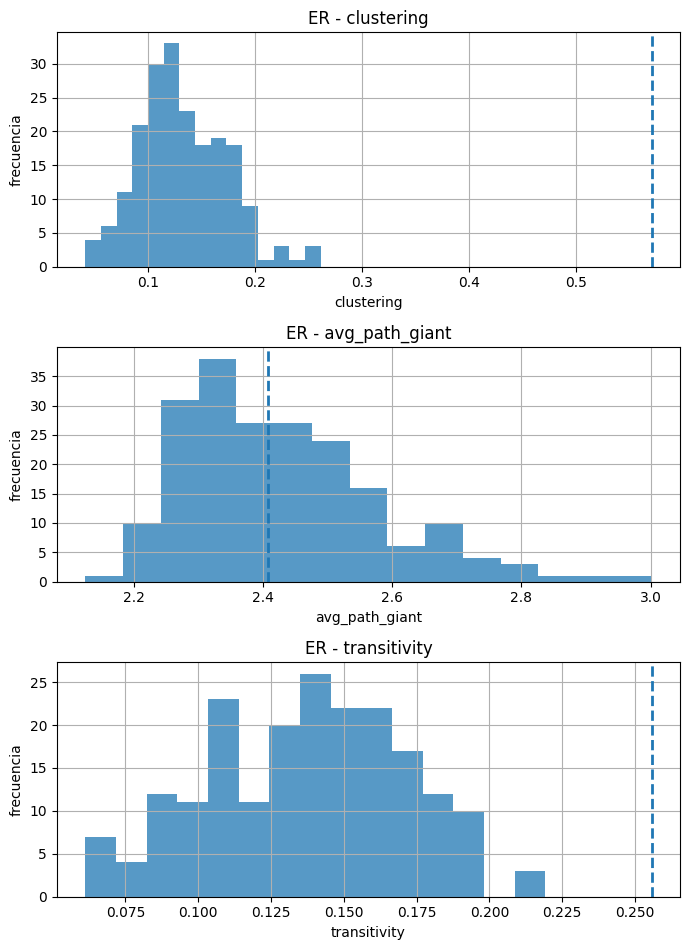

In [10]:

plot_metric_distributions(er_df, real_karate, ["clustering", "avg_path_giant", "transitivity"], title_prefix="ER - ")



### Interpretación
En Karate Club:
- la **distancia media** no difiere dramáticamente de ER;
- el **clustering** sí es bastante mayor en la red real.

Esa es exactamente la idea de esta clase:
**no confundir caminos cortos con evidencia suficiente de estructura compleja**.



## 4. Baseline 2 — Configuration model

Este baseline controla algo más fuerte que ER:

- preserva la **secuencia de grados** exacta;
- aleatoriza el resto.

La pregunta ahora es:

> **¿La red real excede lo esperable dado el grado de cada nodo?**


In [11]:

deg_seq = [d for _, d in G.degree()]

def simulate_configuration_metrics(deg_seq, reps=200, seed=42):
    rows = []
    for r in range(reps):
        H = sample_simple_graph_with_same_degree_sequence(deg_seq, seed=seed + r)
        rows.append(basic_metrics_undirected(H))
    return pd.DataFrame(rows)

cfg_df = simulate_configuration_metrics(deg_seq, reps=200, seed=SEED)
compare_real_vs_simulations(
    real_karate,
    cfg_df,
    ["clustering", "avg_path_giant", "assortativity", "transitivity"]
)

,metric,real,sim_mean,sim_std,z_like
0,clustering,0.570638,0.357660,0.050725,4.198709
1,avg_path_giant,2.408200,2.248004,0.045734,3.502771
2,assortativity,-0.475613,-0.304263,0.045266,-3.785414
3,transitivity,0.255682,0.221790,0.024540,1.381106


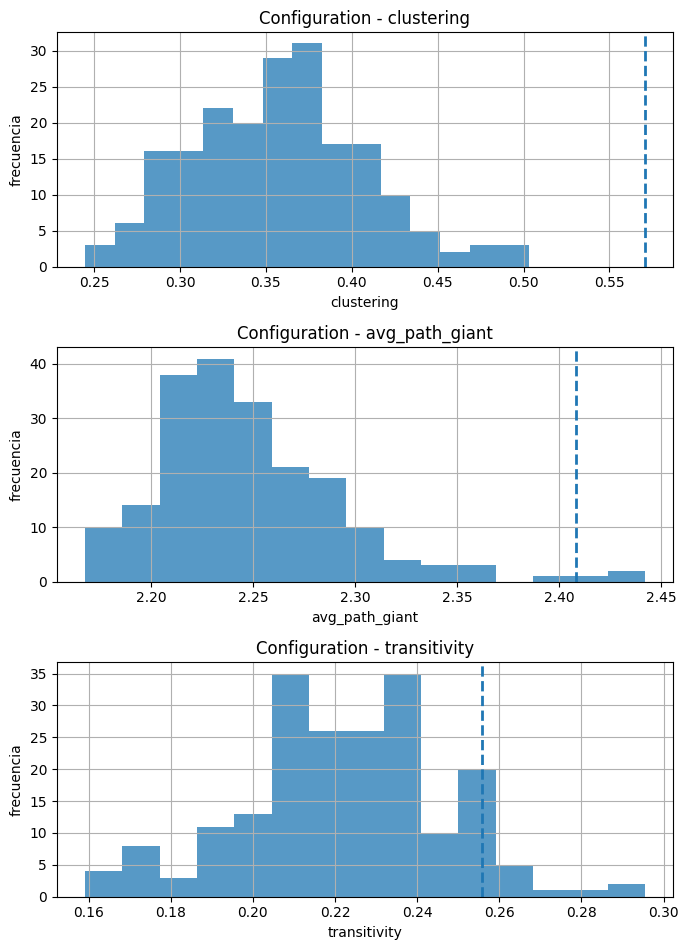

In [12]:

plot_metric_distributions(cfg_df, real_karate, ["clustering", "avg_path_giant", "transitivity"], title_prefix="Configuration - ")



### Qué mirar
Si la diferencia en clustering sigue siendo alta incluso contra configuration model, entonces:

- la señal **no** se explica solo por grado;
- hay estructura residual: cierre triádico, bloques, homofilia, procesos sociales, etc.


**Qué observamos?**
Al comparar la red real con un **configuration model** que preserva exactamente la secuencia de grados, vemos que:

* **Clustering:** la red real tiene un clustering claramente **más alto** que el esperado bajo ese nulo. Por tanto, la heterogeneidad de grados **no basta** para explicar el cierre triádico observado.
* **Distancia media en la componente gigante:** la red real tiene una distancia media **algo mayor** que la esperada en las redes aleatorizadas con el mismo grado. Eso sugiere una estructura menos “mezclada al azar” y más organizada localmente.
* **Transitividad:** la red real está **cerca del extremo alto** de lo esperado bajo el nulo, pero no completamente fuera del rango. Hay evidencia más moderada de exceso de cierre global que en el clustering medio.

**Conclusión general**
La secuencia de grados explica una parte importante de la estructura, pero **no toda**. En particular, el exceso de clustering indica que la red real contiene organización adicional --por ejemplo, cierre triádico o estructura de comunidades-- que no se obtiene solo preservando los grados.



## 5. Baseline 3 - Degree-preserving rewiring

Aquí no generamos una red “nueva desde cero”.  
Tomamos la red real y la **rewireamos** aleatoriamente preservando el grado de cada nodo.

Esto es muy útil para estudiar:
- clustering residual
- assortativity residual
- modularidad residual
- motifs y rich-club, si luego agregas esas métricas.


In [13]:

def simulate_degree_preserving_rewire_metrics(G, reps=200, nswap_factor=10, seed=42):
    rows = []
    m = G.number_of_edges()
    for r in range(reps):
        H = G.copy()
        nx.double_edge_swap(H, nswap=nswap_factor*m, max_tries=100*nswap_factor*m, seed=seed+r)
        rows.append(basic_metrics_undirected(H))
    return pd.DataFrame(rows)

rewire_df = simulate_degree_preserving_rewire_metrics(G, reps=200, nswap_factor=10, seed=SEED)
compare_real_vs_simulations(real_karate, rewire_df, ["clustering", "avg_path_giant", "assortativity", "transitivity"])


,metric,real,sim_mean,sim_std,z_like
0,clustering,0.570638,0.356672,0.049315,4.338757
1,avg_path_giant,2.408200,2.248512,0.046855,3.408140
2,assortativity,-0.475613,-0.300621,0.050939,-3.435355
3,transitivity,0.255682,0.223778,0.027577,1.156889


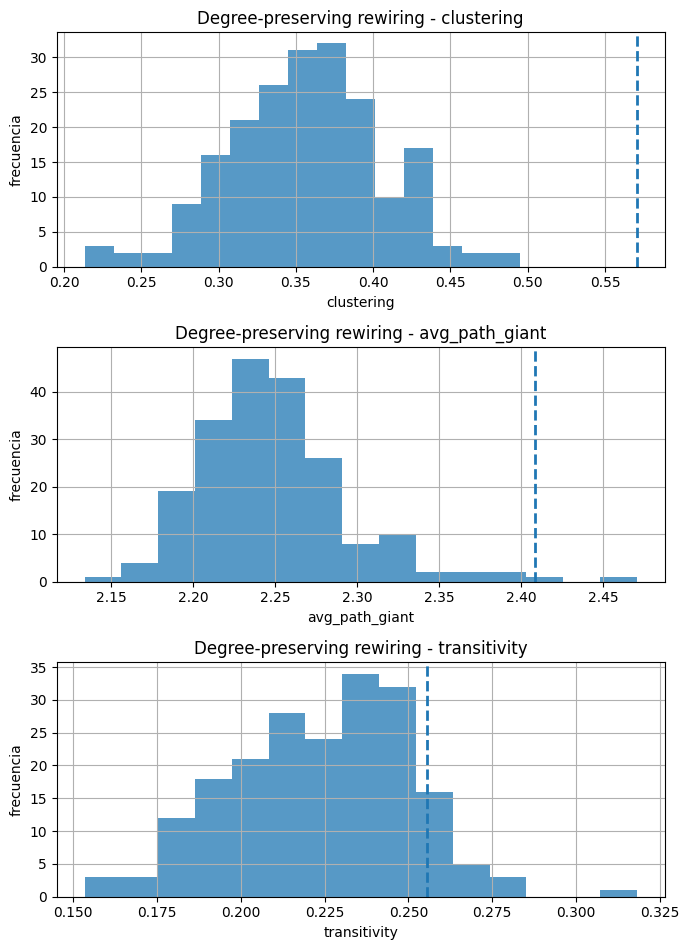

In [14]:

plot_metric_distributions(rewire_df, real_karate, ["clustering", "avg_path_giant", "transitivity"], title_prefix="Degree-preserving rewiring - ")


**Interpretación**
Al comparar la red real con versiones aleatorizadas mediante **degree-preserving rewiring**, vemos que:

* **Clustering:** la red real tiene un clustering **mucho mayor** que el esperado después de rewirear manteniendo exactamente el grado de cada nodo. Esto indica que el cierre triádico observado no se explica solo por la secuencia de grados.
* **Distancia media en la componente gigante:** la red real presenta una distancia media **mayor** que la de las redes rewired. Eso sugiere una estructura menos aleatoria y más local o modular.
* **Transitividad:** la red real está alta, pero no claramente fuera de la distribución. Está cerca del extremo superior, así que la evidencia de exceso de transitividad global es débil a moderada, no fuerte.

**Conclusión general**
El resultado fuerte está en clustering y distancia media, no tanto en transitividad.
Eso sugiere que la red real tiene más cierre local y menos mezcla aleatoria que las redes rewired, pero el exceso de transitividad global no parece tan extraordinario una vez que controlas por la secuencia de grados.

## En resumen

Bajo degree-preserving rewiring, la red real muestra un clustering claramente mayor y una distancia media también mayor que las simulaciones. En cambio, la transitividad de la red real cae cerca del extremo alto pero aún dentro del rango esperado. En consecuencia, la evidencia más fuerte de estructura no explicada por el grado está en el cierre local promedio y en la mayor separación promedio, más que en la transitividad global.


## 6. Baseline 4 — SBM con bloques conocidos

Karate Club incluye una partición histórica famosa: `club = {Mr. Hi, Officer}`.

Usaremos esa variable como **bloque conocido** y estimaremos una matriz de probabilidades de conexión:
- dentro de bloque;
- entre bloques.

La pregunta es:

> **¿La organización relevante se entiende mejor como estructura de bloques que como puro grado individual?**


In [15]:
## Baseline de modularidad: matriz de conexión entre los grupos de la red original.
clubs = nx.get_node_attributes(G, "club")
labels = sorted(set(clubs.values()))
groups = {lab: [n for n, c in clubs.items() if c == lab] for lab in labels}
sizes = [len(groups[lab]) for lab in labels]

P = np.zeros((2, 2))
for i, li in enumerate(labels):
    ## Para cada par de grupos (li, lj), calculamos la proporción de aristas entre esos grupos en el grafo original. 
    # Para el caso i == j, contamos las aristas dentro del mismo grupo y dividimos por el número de pares posibles 
    # dentro de ese grupo. Para el caso i != j, contamos las aristas entre los dos grupos y dividimos por el 
    # número de pares posibles entre esos grupos.
    Si = set(groups[li])
    for j, lj in enumerate(labels):
        Sj = set(groups[lj])
        if i == j:
            possible = sizes[i] * (sizes[i] - 1) / 2
            edges = sum(1 for u, v in G.edges() if u in Si and v in Si)
        else:
            possible = sizes[i] * sizes[j]
            edges = sum(1 for u, v in G.edges() if (u in Si and v in Sj) or (u in Sj and v in Si))
        P[i, j] = edges / possible

P


array([[0.25735294, 0.03806228],
       [0.03806228, 0.23529412]])

In [16]:

def karate_sbm_sample(sizes, P, labels, seed=42):
    H = nx.stochastic_block_model(sizes, P, seed=seed)
    club_attr = {}
    idx = 0
    for lab, size in zip(labels, sizes):
        for _ in range(size):
            club_attr[idx] = lab
            idx += 1
    nx.set_node_attributes(H, club_attr, "club")
    return H

def simulate_sbm_metrics(sizes, P, labels, reps=200, seed=42):
    rows = []
    for r in range(reps):
        H = karate_sbm_sample(sizes, P, labels, seed=seed+r)
        metrics = basic_metrics_undirected(H)
        metrics["club_assortativity"] = nx.attribute_assortativity_coefficient(H, "club")
        rows.append(metrics)
    return pd.DataFrame(rows)

real_karate_plus = dict(real_karate)
real_karate_plus["club_assortativity"] = nx.attribute_assortativity_coefficient(G, "club")

sbm_df = simulate_sbm_metrics(sizes, P, labels, reps=200, seed=SEED)
compare_real_vs_simulations(real_karate_plus, sbm_df, ["clustering", "avg_path_giant", "club_assortativity"])


,metric,real,sim_mean,sim_std,z_like
0,clustering,0.570638,0.183219,0.048285,8.023520
1,avg_path_giant,2.408200,2.522324,0.161713,-0.705721
2,club_assortativity,0.717531,0.714928,0.070520,0.036907


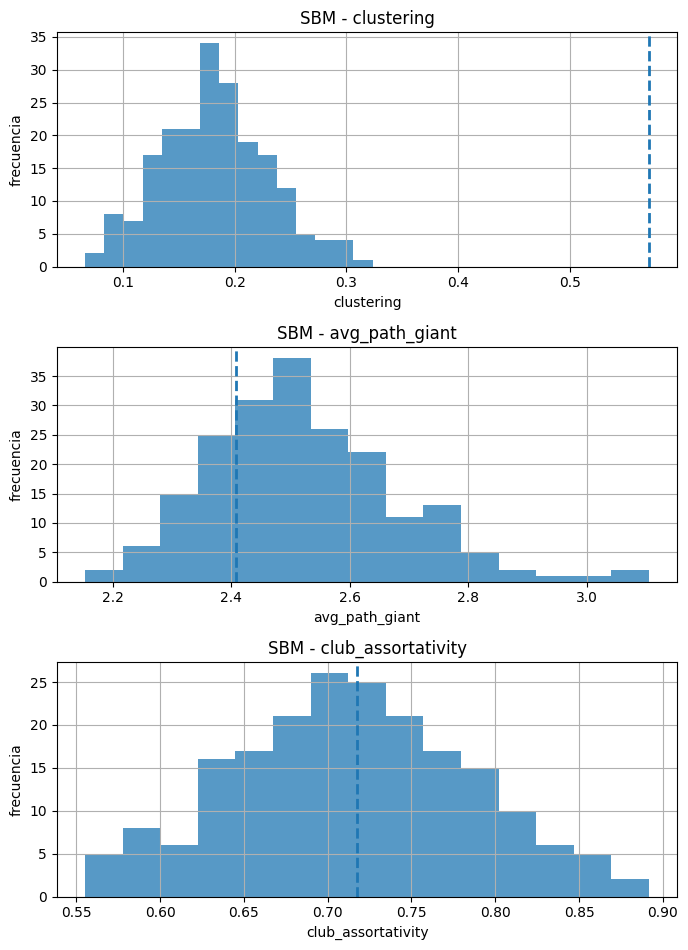

In [17]:

plot_metric_distributions(sbm_df, real_karate_plus, ["clustering", "avg_path_giant", "club_assortativity"], title_prefix="SBM - ")



### Lectura
El SBM no es un “nulo puro”, sino un **baseline estadístico** cuando la hipótesis central es de **bloques** o **equivalencia estocástica**.

Si el SBM reproduce mejor ciertas métricas que ER o configuration, eso sugiere que la organización comunitaria sí es parte importante del sistema.


**Interpretación**
Al comparar la red real con muestras de un **SBM** calibrado por bloques (“club”), vemos que:

* **Clustering:** la red real está **muy por encima** de la distribución simulada. Por tanto, incluso modelando explícitamente la estructura de bloques, el SBM **subestima fuertemente** el cierre local observado.
* **Distancia media en la componente gigante:** la red real cae **cerca del borde izquierdo** de la distribución simulada, pero **todavía dentro del rango**. Es decir, el SBM reproduce razonablemente esta métrica, aunque tiende a generar caminos algo más largos.
* **Asortatividad por club:** la red real cae **muy cerca del centro** de la distribución simulada. Aquí el SBM sí captura bien la mezcla por atributo de bloque.

**Conclusión general**
El SBM explica bastante bien la **separación por club** y de forma aceptable la **distancia media**, pero **no explica el clustering** de la red real. Eso sugiere que la pertenencia a bloques no basta: además de estructura comunitaria, hay **cierre triádico adicional** o dependencia local que el SBM estándar no incorpora.

## En resumen

**El SBM acierta en la mezcla por club, aproxima la distancia media, pero falla fuerte en clustering.** La red real tiene más cierre local que el esperable solo por estructura de bloques.

## Importante

> Tener comunidades no implica automáticamente reproducir triángulos. Un SBM puede capturar mezcla entre grupos y aun así subestimar el cierre triádico dentro de esos grupos.
---

## Comparación final de baselines: qué explica y qué no

| Baseline                       | Qué preserva / modela                                 | Qué logra explicar en Karate                                                                         | Qué no logra explicar                                                                            |
| ------------------------------ | ----------------------------------------------------- | ---------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------ |
| **ER**                         | Tamaño y densidad esperada                            | Sirve como referencia mínima de azar homogéneo; útil para ver que la red real no es “solo aleatoria” | No reproduce heterogeneidad de grados, ni clustering alto, ni estructura comunitaria             |
| **Configuration model**        | Secuencia de grados                                   | Explica parte de la estructura asociada a la heterogeneidad de grados                                | La red real sigue teniendo más clustering y distancias algo mayores; el grado no basta           |
| **Degree-preserving rewiring** | Exactamente la secuencia de grados en un grafo simple | Muy buen control para preguntar qué parte de la red se debe solo al grado                            | La red real mantiene más cierre local y mayor separación media; hay estructura adicional         |
| **SBM**                        | Estructura de bloques / mezcla por club               | Reproduce bien la asortatividad por club y razonablemente la distancia media                         | Subestima fuertemente el clustering; la comunidad sola no basta para explicar el cierre triádico |

---

## Lectura conceptual

Los cuatro baselines muestran una jerarquía útil:

* **ER** controla muy poco: sirve como nulo mínimo.
* **Configuration** y **rewiring** controlan la **degree sequence**: muestran qué parte de la estructura se debe solo a los grados.
* **SBM** controla la **estructura de bloques**: muestra qué parte se explica por comunidades o grupos.

Lo importante es que **ninguno por sí solo explica todo**.

---

## Conclusión

> La red Karate no se explica solo por azar, ni solo por la secuencia de grados, ni solo por estructura de bloques.
> El patrón más persistente es el exceso de **clustering**, lo que sugiere **cierre triádico adicional** o dependencia local más fuerte que la capturada por estos baselines.

---


**Resumen:**

* **ER**: demasiado simple.
* **Configuration / rewiring**: controlan grado, pero no explican todo el cierre local.
* **SBM**: captura bien los bloques, pero no los triángulos.
* **Señal residual principal**: **clustering alto no explicado**.

---

## Take away

> Un baseline útil no es el que “se parece más” a la red real en todo, sino el que permite aislar qué mecanismo sí y qué mecanismo no alcanza para explicar la estructura observada.

---


## 7. Weighted null — Les Misérables

**Les Misérables** es una red clásica de coaparición de personajes en la novela de Victor Hugo.

* **Nodos:** personajes.
* **Aristas:** dos personajes están conectados si aparecen en la misma escena o capítulo.
* **Peso (`weight`):** número de coapariciones entre ambos personajes.

Es un buen ejemplo de **red ponderada**, porque no solo importa si dos personajes están conectados, sino también **cuán fuerte** es esa relación según la frecuencia con que aparecen juntos.


Para redes ponderadas, a veces el control correcto no es solo topológico.  
Aquí usamos una red real con pesos (`weight`) y construimos un null que:

- **preserva la topología binaria**;
- **preserva el conjunto de pesos**;
- pero **permuta la ubicación de los pesos** sobre las aristas.

La pregunta es:

> **¿La colocación de pesos observada parece especial o sería similar si los pesos estuvieran distribuidos aleatoriamente sobre la misma topología?**


In [18]:

LM = nx.les_miserables_graph()
weighted_real = {
    "weighted_avg_clustering": nx.average_clustering(LM, weight="weight"),
    "unweighted_avg_clustering": nx.average_clustering(nx.Graph(LM)),
    "n": LM.number_of_nodes(),
    "m": LM.number_of_edges(),
}
pd.DataFrame([weighted_real]).T.rename(columns={0: "Les Mis"})


,Les Mis
weighted_avg_clustering,0.055027
unweighted_avg_clustering,0.573137
n,77.000000
m,254.000000


In [19]:

def shuffle_edge_weights_null(G, seed=42):
    # Dado un grafo ponderado G, devuelve un nuevo grafo con la misma topología pero con 
    # los pesos de las aristas mezclados aleatoriamente. La función asegura que los pesos 
    # se asignen a las mismas aristas pero en un orden aleatorio, lo que permite evaluar 
    # el impacto de la asignación de pesos sobre las métricas de la red.
    rng = random.Random(seed)
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    edges = list(G.edges())
    weights = [G[u][v]["weight"] for u, v in edges]
    rng.shuffle(weights)
    for (u, v), w in zip(edges, weights):
        H.add_edge(u, v, weight=w)
    return H

def simulate_weight_shuffle_metrics(G, reps=200, seed=42):
    # Dado un grafo ponderado G, simula la métrica de clustering promedio ponderado y no 
    # ponderado en grafos donde los pesos de las aristas han sido mezclados aleatoriamente. 
    # Devuelve un DataFrame con los resultados de las simulaciones.
    rows = []
    for r in range(reps):
        H = shuffle_edge_weights_null(G, seed=seed+r)
        rows.append({
            "weighted_avg_clustering": nx.average_clustering(H, weight="weight"),
            "unweighted_avg_clustering": nx.average_clustering(nx.Graph(H)),
        })
    return pd.DataFrame(rows)

w_df = simulate_weight_shuffle_metrics(LM, reps=200, seed=SEED)
compare_real_vs_simulations(weighted_real, w_df, ["weighted_avg_clustering", "unweighted_avg_clustering"])


,metric,real,sim_mean,sim_std,z_like
0,weighted_avg_clustering,0.055027,0.046455,0.001977,4.336929
1,unweighted_avg_clustering,0.573137,0.573137,0.000000,NaN


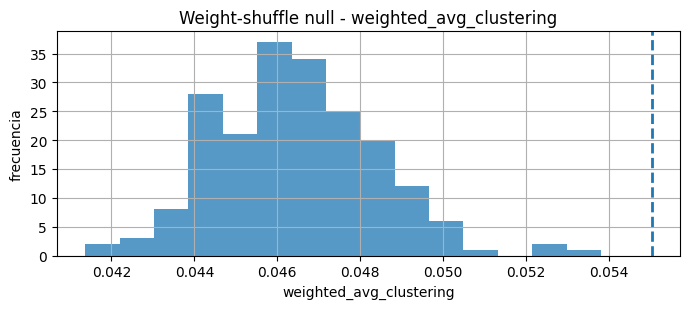

In [20]:

plot_metric_distributions(w_df, weighted_real, ["weighted_avg_clustering"], title_prefix="Weight-shuffle null - ")



### Comentario
Este ejercicio no “prueba” un mecanismo causal, pero sí sirve como test de sensibilidad:

- si el clustering ponderado real cae muy fuera de la distribución nula, entonces la **asignación de pesos** contiene señal;
- si no, buena parte de la métrica podría venir simplemente de la topología binaria.


**Interpretación**
Al mantener fija la topología de *Les Misérables* y solo **barajar los pesos entre las mismas aristas**, el **clustering ponderado real** queda claramente **por encima** de lo esperado bajo el nulo. En cambio, el **clustering no ponderado** no cambia, porque la estructura binaria de la red se mantiene exactamente igual.

**Conclusión**
La ubicación observada de los pesos **no es aleatoria**: los pesos altos están distribuidos de una forma que **refuerza más el cierre local** que lo que obtendríamos si los pesos se asignaran al azar sobre la misma topología.

## En resumen

**La topología sola no basta:** en *Les Misérables*, la forma en que se ubican los pesos sobre las aristas genera **más clustering ponderado** que el esperado por azar.

---


## 8. Red bipartita real: Davis Southern Women

Ahora cambiamos de objeto.  
Esta red **no** debe analizarse como si fuera una red 1-mode cualquiera.

Aquí tenemos:
- un modo de **personas**;
- un modo de **eventos**;
- enlaces solo entre modos distintos.

La advertencia metodológica central es:

> **no interpretar clustering alto en una proyección 1-mode sin un baseline bipartito**.


In [21]:

B = nx.davis_southern_women_graph()
top = {n for n, d in B.nodes(data=True) if d["bipartite"] == 0}      # mujeres
bottom = set(B) - top                                                 # eventos

bip_summary = {
    "n_top": len(top),
    "n_bottom": len(bottom),
    "m": B.number_of_edges(),
    "density_bipartite": B.number_of_edges() / (len(top) * len(bottom)),
}
proj_summary, P_real = summarize_projection(B, top)
bip_summary.update(proj_summary)
bip_summary.update(redundancy_summary(B, top))
pd.DataFrame([bip_summary]).T.rename(columns={0: "Davis Southern Women"})


,Davis Southern Women
n_top,18.000000
n_bottom,14.000000
m,89.000000
density_bipartite,0.353175
proj_nodes,18.000000
proj_edges,139.000000
proj_density,0.908497
proj_clustering_unweighted,0.936687
mean_redundancy,0.978571
median_redundancy,1.000000



## 9. Null bipartito 1 — mismo tamaño y mismo número de enlaces

Este es el análogo más cercano a ER para bipartitas.

Preserva:
- número de nodos en cada modo;
- número total de enlaces.

No preserva:
- secuencia de grados del modo top;
- secuencia de grados del modo bottom.

Sirve como **baseline muy débil**.


In [22]:
## Baseline de bipartito aleatorio con mismo número de nodos y aristas, pero sin preservar grados ni estructura.
B_rand, top_rand, bottom_rand = bipartite_random_same_size(len(top), len(bottom), B.number_of_edges(), seed=SEED)
rand_summary, P_rand = summarize_projection(B_rand, top_rand)
rand_summary.update(redundancy_summary(B_rand, top_rand))
pd.DataFrame([rand_summary]).T.rename(columns={0: "Bipartite random same-size"})


,Bipartite random same-size
proj_nodes,18.000000
proj_edges,130.000000
proj_density,0.849673
proj_clustering_unweighted,0.898555
mean_redundancy,0.885009
median_redundancy,0.933333



## 10. Null bipartito 2 — preservando grados de ambos modos

Aquí hacemos un **rewiring bipartito** que conserva:
- grados del modo top;
- grados del modo bottom;
- naturaleza bipartita del grafo.

Este es, en la práctica, el baseline más útil para redes de afiliación.


In [23]:
# Baseline de bipartito con mismo número de nodos y aristas, pero preservando grados en el conjunto superior.
B_deg, swaps_done, tries_done = bipartite_degree_preserving_swap(B, top, nswap=2000, seed=SEED)
deg_summary, P_deg = summarize_projection(B_deg, top)
deg_summary.update(redundancy_summary(B_deg, top))

print(f"Swaps realizados: {swaps_done} / intentos: {tries_done}")
pd.DataFrame([deg_summary]).T.rename(columns={0: "Bipartite degree-preserving"})


Swaps realizados: 2000 / intentos: 7645


,Bipartite degree-preserving
proj_nodes,18.000000
proj_edges,135.000000
proj_density,0.882353
proj_clustering_unweighted,0.931827
mean_redundancy,0.846958
median_redundancy,0.902381



## 11. Comparación directa: red real vs nulos bipartitos

Vamos a comparar:
- número de enlaces en la proyección;
- densidad de la proyección;
- clustering en la proyección;
- redundancia media sobre el modo top.

Así se ve con claridad por qué la proyección puede inflar estructura de manera mecánica.


In [24]:

bip_compare = pd.DataFrame([
    {"modelo": "Real", **proj_summary, **redundancy_summary(B, top)},
    {"modelo": "Random same-size", **rand_summary},
    {"modelo": "Degree-preserving", **deg_summary},
])
bip_compare


,modelo,proj_nodes,proj_edges,proj_density,proj_clustering_unweighted,mean_redundancy,median_redundancy
0,Real,18,139,0.908497,0.936687,0.978571,1.000000
1,Random same-size,18,130,0.849673,0.898555,0.885009,0.933333
2,Degree-preserving,18,135,0.882353,0.931827,0.846958,0.902381


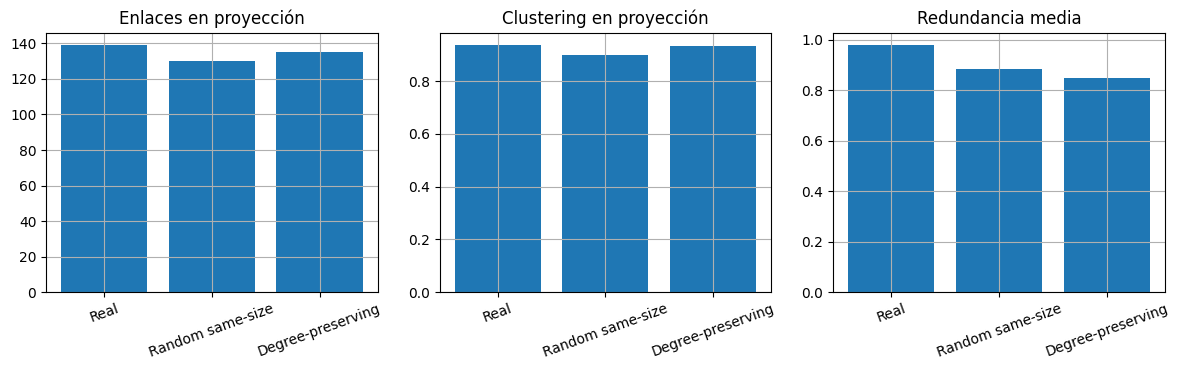

In [25]:

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

labels = bip_compare["modelo"]
axes[0].bar(labels, bip_compare["proj_edges"])
axes[0].set_title("Enlaces en proyección")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(labels, bip_compare["proj_clustering_unweighted"])
axes[1].set_title("Clustering en proyección")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(labels, bip_compare["mean_redundancy"])
axes[2].set_title("Redundancia media")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()



### Lectura
En esta red, la proyección 1-mode es naturalmente muy densa y muy clusterizada.  
Por eso:

- un clustering alto en la proyección **no** es evidencia suficiente de estructura sustantiva;
- parte importante puede venir de la **estructura bipartita misma**;
- el null que preserva grados de ambos modos es mucho más informativo que el bipartito aleatorio simple.


**Interpretación**
En esta red bipartita, la proyección real sobre mujeres se parece bastante a los nulos en **número de enlaces** y **clustering**. Eso sugiere que una parte importante de esas métricas puede explicarse por la estructura bipartita básica, especialmente cuando se preservan los grados. La diferencia más visible aparece en **redundancia**, que es mayor en la red real.

**Implicancia metodológica**
En redes bipartitas, **alto clustering en la proyección no es evidencia suficiente** de estructura social especial, porque puede emerger mecánicamente por la propia proyección. Por eso conviene comparar siempre contra nulos bipartitos y mirar métricas más informativas, como **redundancia** u otras medidas definidas sobre la bipartita original.

**Entocnes**
No interpreten la proyección sola. Primero pregunten:
**¿esto es realmente señal social o podría aparecer igual por la forma bipartita de los datos?**

---


## 12. Resumen: qué baseline usar según la pregunta

### Redes tradicionales
- **ER**: primer control de tamaño y densidad.
- **Configuration model**: cuando la heterogeneidad de grado importa.
- **Degree-preserving rewiring**: para clustering residual, assortativity residual y motifs.
- **SBM**: cuando la hipótesis relevante es de bloques/grupos/comunidades.
- **Weighted nulls**: cuando importa cómo se asignan pesos sobre la topología.

### Redes bipartitas
- **Random same-size bipartite**: control débil.
- **Bipartite degree-preserving null**: baseline serio para afiliación/coautoría/eventos.
- **Proyección sin baseline**: mala práctica si luego quieres interpretar clustering.



## 13. Checklist de model checking para la tarea

Cuando redactes el memo de interpretación, deja explícito:

1. **Qué red real modelaste** y qué decisiones tomaste.
2. **Qué baseline** usaste.
3. **Qué preserva** y **qué no preserva** ese baseline.
4. **Qué métricas comparaste**.
5. **Qué patrón sí explica** el baseline.
6. **Qué patrón no explica** el baseline.
7. **Qué hipótesis queda abierta** después del contraste.



## 14. Extensiones sugeridas

1. Agregar **modularidad** y compararla contra degree-preserving rewiring.
2. Medir **rich-club** y contrastarlo con configuration model.
3. En redes dirigidas, construir un null que preserve:
   - `in-degree`,
   - `out-degree`,
   - y opcionalmente reciprocidad.
4. En redes con atributos, comparar contra un null que preserve geografía, tamaño institucional o etiquetas relevantes.



## 15. La idea fuerte de esta clase es simple:



> **Antes de interpretar una métrica de red, compárala con una referencia adecuada.**

Ese paso separa la descripción ingenua del análisis serio.
